In [1]:
import pandas as pd

from email_outreach.experiment_utils.metric_loader import load_experiment_metrics
from email_outreach.ml.shallow_autoencoder.abstract_contextual_model import AbstractContextualModel
from email_outreach.utils.constants import ROOT_FOLDER
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def get_precisions_recalls(path: Path, quantiles=1 - np.linspace(start=0, stop=1, num=100)):
    experiments: list[list] = load_experiment_metrics(path)
    recalls: list[float] = []
    precisions: list[float] = []
    for experiment in experiments:
        recall, precision = AbstractContextualModel.calculate_recall_precision_at_quantiles(experiment,
                                                                                            quantiles=quantiles)[1:3]

        recalls.append(recall)
        precisions.append(precision)

    return recalls, precisions

In [3]:
def get_recalls_auc(path: Path):
    experiments: list[list] = load_experiment_metrics(path)
    recalls_auc: list[float] = []
    for experiment in experiments:
        recall_auc = AbstractContextualModel.calculate_partial_auc(experiment)
        recalls_auc.append(recall_auc)

    return recalls_auc

In [4]:
def delta_pct(lhs: np.ndarray, rhs: np.ndarray, decimals: int = 2 ) -> np.ndarray:
    return ((lhs-rhs)*100).round(decimals)

In [5]:
f_p_phi_path: Path = ROOT_FOLDER / "experiments" / "test_set" / "1" / "contextual_bandit" / "f_p_phi_alpha_v3"

# imp_s_path: Path = ROOT_FOLDER / "experiments" / "test_set" / "1" / "contextual_bandit" / "f_p_phi_plug_v3"

baseline_path: Path = ROOT_FOLDER / "experiments" / "test_set" / "1" / "contextual_bandit" / "baseline_v2"

In [6]:
f_p_phi_recalls, f_p_phi_precisions = get_precisions_recalls(f_p_phi_path)
baseline_recalls, baseline_precisions = get_precisions_recalls(baseline_path)
# imp_s_recalls, imp_s_precisions = get_precisions_recalls(imp_s_path)

In [7]:
f_p_phi_recalls_auc = get_recalls_auc(f_p_phi_path)
baseline_recalls_auc = get_recalls_auc(baseline_path)
# imp_s_recalls_auc = get_recalls_auc(imp_s_path)

In [8]:
np.array(f_p_phi_recalls_auc).mean(), np.array(baseline_recalls_auc).mean()

(np.float64(0.9143009654841028), np.float64(0.8937074946193079))

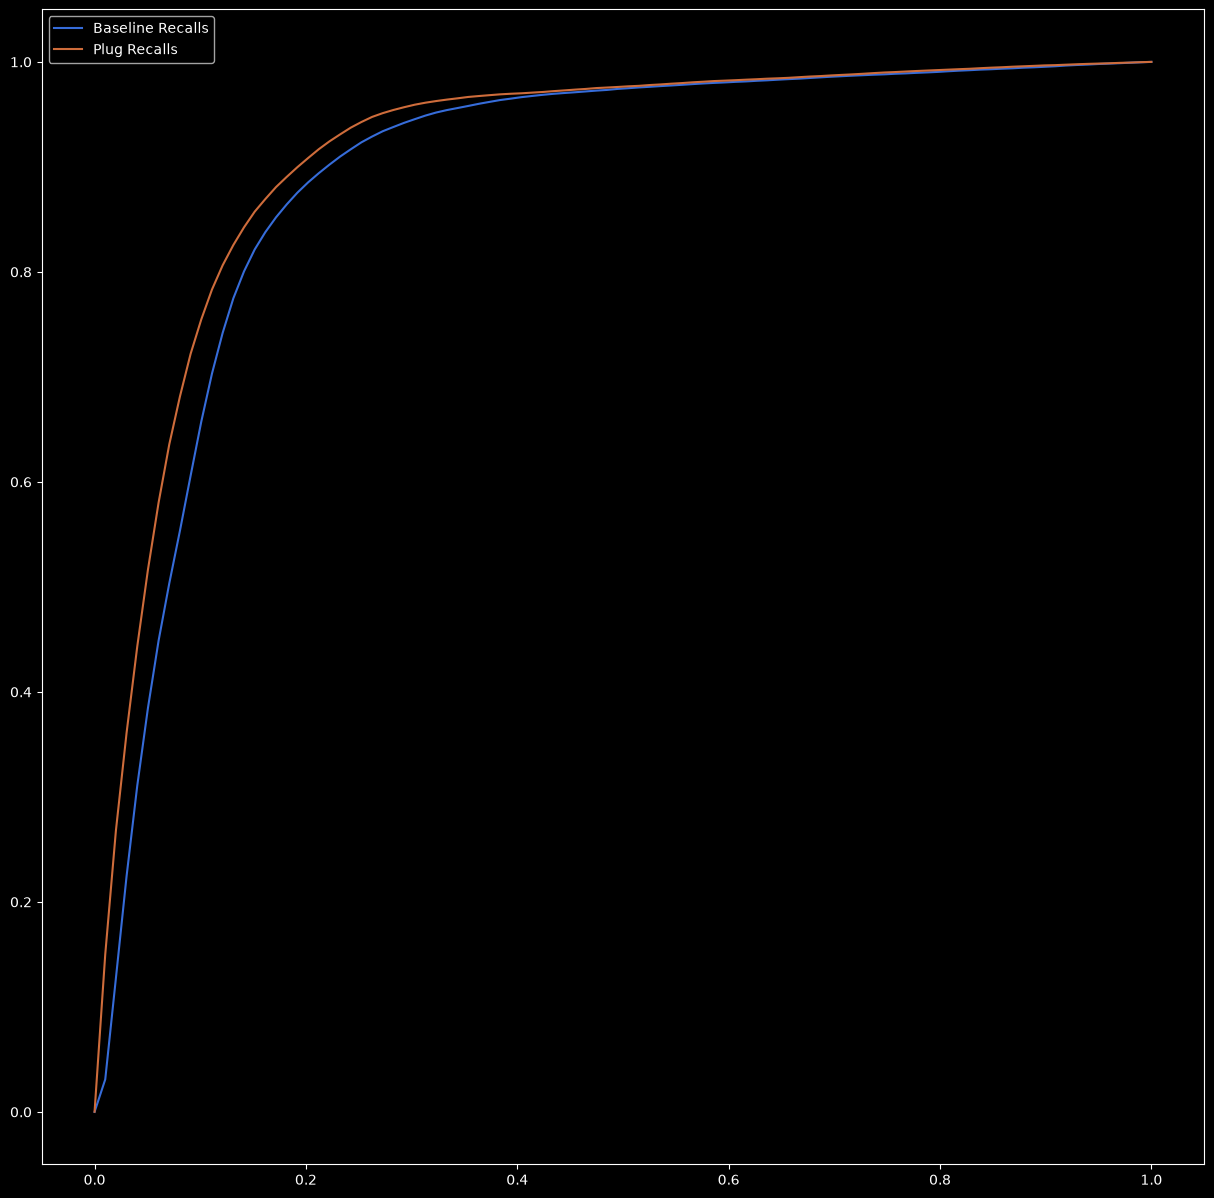

In [9]:
plt.figure(figsize=(15, 15))


plt.plot(np.linspace(start=0, stop=1, num=100), np.array(baseline_recalls).mean(axis=0),
         label="Baseline Recalls")
plt.plot(np.linspace(start=0, stop=1, num=100), np.array(f_p_phi_recalls).mean(axis=0),
         label="Plug Recalls")
# plt.plot(np.linspace(start=0, stop=1, num=100), np.array(imp_s_recalls).mean(axis=0),
#          label="Improved S Recalls")

plt.legend()

In [10]:
delta_pct(
    np.array(f_p_phi_recalls).mean(axis=0),
    np.array(baseline_recalls).mean(axis=0),
    decimals=1
)

array([ 0. , 11.9, 14.1, 13.6, 13.3, 13.2, 13.1, 13.2, 12.8, 11.6,  9.7,
        8. ,  6.4,  5.1,  4.2,  3.6,  3.2,  2.9,  2.6,  2.4,  2.3,  2.3,
        2.2,  2.1,  2.1,  1.9,  1.9,  1.7,  1.6,  1.5,  1.4,  1.2,  1.1,
        1. ,  0.9,  0.9,  0.7,  0.6,  0.5,  0.5,  0.4,  0.3,  0.3,  0.3,
        0.2,  0.3,  0.2,  0.2,  0.2,  0.2,  0.2,  0.2,  0.2,  0.2,  0.2,
        0.2,  0.2,  0.2,  0.2,  0.2,  0.2,  0.2,  0.2,  0.2,  0.1,  0.1,
        0.1,  0.1,  0.1,  0.1,  0.1,  0.1,  0.1,  0.2,  0.2,  0.2,  0.2,
        0.2,  0.2,  0.2,  0.2,  0.1,  0.1,  0.1,  0.1,  0.1,  0.2,  0.1,
        0.1,  0.1,  0.1,  0.1,  0.1,  0.1,  0. ,  0. ,  0. ,  0. ,  0. ,
        0. ])